**Задание 17 – CША**

**Сжатие изображения с помощью усечения спектра**  
Реализуйте алгоритм сжатия, основанный на сохранении только определённого процента самых больших коэффициентов Фурье-спектра.

**Что нужно сделать:**  
Вычислить двумерное БПФ изображения.  
Отсортировать амплитуды всех частотных коэффициентов по убыванию.  
Оставить только N% (например, 10%, 5%, 1%) коэффициентов с наибольшей амплитудой, остальные обнулить.  
Выполнить обратное БПФ и получить восстановленное изображение.  
Оценить качество сжатия: визуально и через PSNR (пиковое отношение сигнал/шум) или MSE. Построить график зависимости PSNR от процента оставленных коэффициентов.  

**Дополнительно:** реализовать сохранение сжатого изображения в виде списка индексов и значений оставшихся коэффициентов, а затем загрузку и восстановление.

Загрузите изображение (JPG или PNG)


Saving catlol.jpeg to catlol.jpeg
Размер изображения: (425, 470)
Всего пикселей: 199750

Результаты сжатия:
--------------------------------------------------
10%: PSNR = 44.90 dB, MSE = 2.1052, Сжатие = 10.0x
5%: PSNR = 41.73 dB, MSE = 4.3612, Сжатие = 20.0x
2%: PSNR = 37.34 dB, MSE = 11.9987, Сжатие = 50.0x
1%: PSNR = 33.55 dB, MSE = 28.7365, Сжатие = 100.0x
0.5%: PSNR = 30.16 dB, MSE = 62.6353, Сжатие = 200.2x


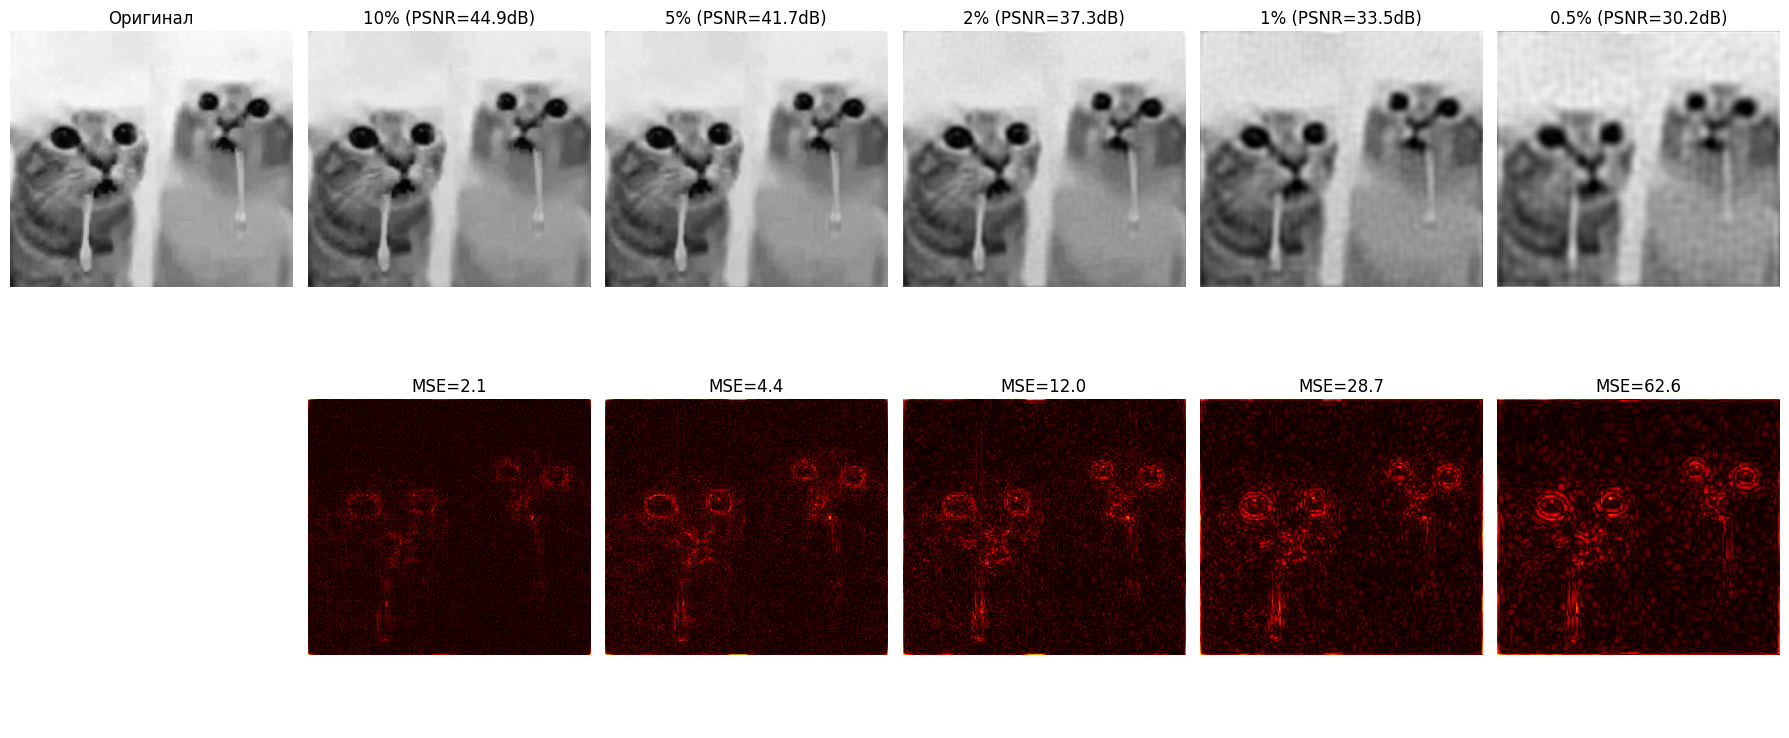

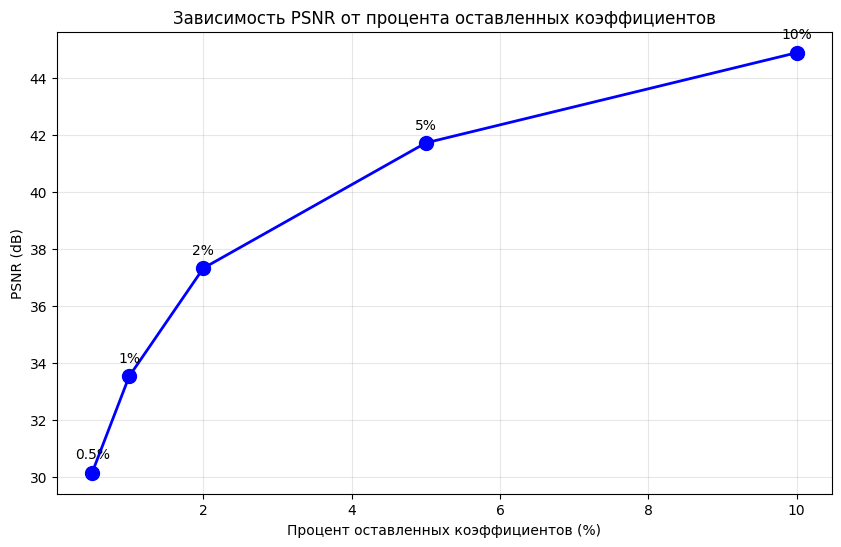


ДОПОЛНИТЕЛЬНОЕ ЗАДАНИЕ
Сохранение сжатого изображения для 5% коэффициентов...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл 'compressed_5percent.json' сохранён и скачан
Загрузка и восстановление изображения...
PSNR при загрузке: 6.05 dB
MSE при загрузке: 16151.4783


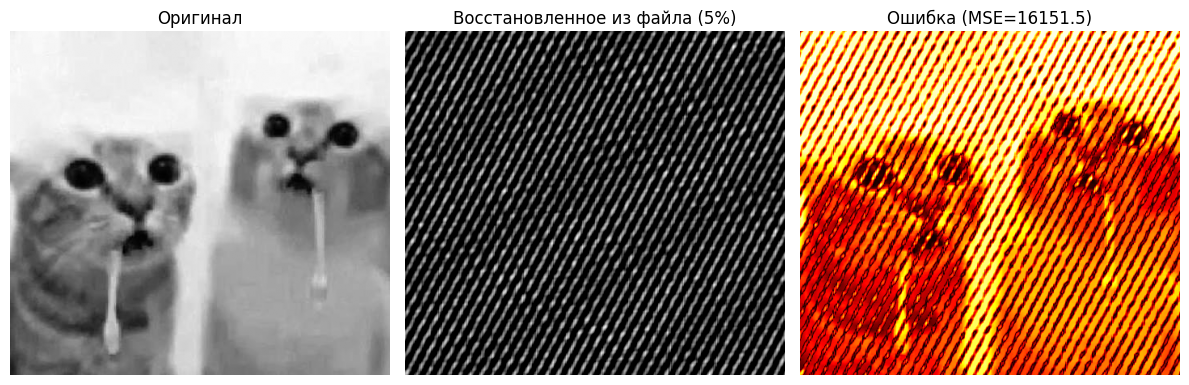


ИТОГОВЫЕ РЕЗУЛЬТАТЫ
Процент | PSNR (dB) | MSE     | Сжатие
---------------------------------------------
   10%  |   44.90   |  2.1052 |   10.0x
    5%  |   41.73   |  4.3612 |   20.0x
    2%  |   37.34   | 11.9987 |   50.0x
    1%  |   33.55   | 28.7365 |  100.0x
  0.5%  |   30.16   | 62.6353 |  200.2x


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import json
from google.colab import files

def compute_fft(image):
    """Вычисляет двумерное БПФ изображения"""
    return np.fft.fftshift(np.fft.fft2(image))

def inverse_fft(fft_spectrum):
    """Выполняет обратное БПФ"""
    return np.fft.ifft2(np.fft.ifftshift(fft_spectrum)).real

def compress_image(image, N_percent):
    """
    Сжатие изображения путём сохранения N% самых больших коэффициентов

    Параметры:
        image: входное изображение
        N_percent: процент сохраняемых коэффициентов (например, 10, 5, 1)

    Возвращает:
        restored: восстановленное изображение
        info: словарь с индексами и значениями коэффициентов
    """
    # 1. Вычисляем двумерное БПФ
    fft = compute_fft(image)

    # 2. Сортируем амплитуды всех частотных коэффициентов по убыванию(Преобразуем изображение в частотную область.)
    amplitudes = np.abs(fft)
    flat_indices = np.argsort(amplitudes.ravel())[::-1]


    # 3. Оставляем только N% коэффициентов с наибольшей амплитудой
    total_coeffs = amplitudes.size
    keep_count = max(1, int(total_coeffs * N_percent / 100))

    # Создаём маску
    mask = np.zeros_like(fft, dtype=bool)
    mask.ravel()[flat_indices[:keep_count]] = True
#flat_indices[:keep_count] - берём первые keep_count индексов (самые большие амплитуды)

    # Обнуляем остальные коэффициенты(Где mask=True - коэффициент остаётся.Где mask=False - коэффициент обнуляется)
    fft_compressed = fft * mask

    # 4. Выполняем обратное БПФ(Выполняем обратное преобразование. np.clip() - обрезаем значения вне диапазона [0, 255]astype(np.uint8) - преобразуем в целые числа (тип для изображений))
    restored = inverse_fft(fft_compressed)
    restored = np.clip(restored, 0, 255).astype(np.uint8)

    # Сохраняем индексы и значения для дополнительного задания(shape - размер изображения (нужен для восстановления)indices - индексы сохранённых коэффициентов values - значения коэффициентов (комплексные числа))
    info = {
        'shape': image.shape,
        'indices': flat_indices[:keep_count].tolist(),
        'values': fft[mask].tolist()
    }

    return restored, info

def calculate_psnr(original, restored):
    """Вычисляет PSNR (пиковое отношение сигнал/шум)"""
    mse = np.mean((original.astype(float) - restored.astype(float)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))
#PSNR (Peak Signal-to-Noise Ratio):
#Вычисляем MSE (среднеквадратичную ошибку) между пикселями
#Используем формулу: PSNR = 20 * log10(MAX / sqrt(MSE))
#MAX = 255 (максимальное значение пикселя)
#PSNR:
#40 dB - отличное качество (почти незаметно)
#30-40 dB - хорошее качество
#20-30 dB - приемлемое качество
#< 20 dB - плохое качество



def calculate_mse(original, restored):
    """Вычисляет MSE (среднеквадратичную ошибку)"""
    return np.mean((original.astype(float) - restored.astype(float)) ** 2)
#MSE (Mean Squared Error):
#Вычисляем средний квадрат разницы между пикселями
#Чем меньше MSE, тем лучше качество

def save_compressed(info, filename='compressed_data.json'):
    """Сохраняет сжатое изображение в виде списка индексов и значений"""
    data = info.copy()
    # Преобразуем комплексные числа для JSON
    data['values'] = [{'real': v.real, 'imag': v.imag} for v in info['values']]
    with open(filename, 'w') as f:
        json.dump(data, f, indent=2)



def load_compressed(filename='compressed_data.json'):
    """Загружает сжатое изображение из файла"""
    with open(filename, 'r') as f:
        data = json.load(f)
    # Восстанавливаем комплексные числа
    data['values'] = [complex(v['real'], v['imag']) for v in data['values']]
    return data

def restore_from_data(info):
    """Восстанавливает изображение из списка индексов и значений"""
    fft = np.zeros(info['shape'], dtype=np.complex128)
    for idx, val in zip(info['indices'], info['values']):
        fft.ravel()[idx] = val
    restored = inverse_fft(fft)
    return np.clip(restored, 0, 255).astype(np.uint8)


#Основная программа

# Загружаем изображение из Colab
print("Загрузите изображение (JPG или PNG)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]


# Открываем изображение и переводим в оттенки серого
image = Image.open(filename).convert('L')
image = np.array(image)

print(f"Размер изображения: {image.shape}")
print(f"Всего пикселей: {image.size}")
print()


# Проценты для тестирования
percents = [10, 5, 2, 1, 0.5]
results = []


# Создаём сетку для визуализации
fig, axes = plt.subplots(2, len(percents) + 1, figsize=(18, 8))


# Отображаем оригинал
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Оригинал')
axes[0, 0].axis('off')
axes[1, 0].axis('off')


print("Результаты сжатия:")
print("-" * 50)

# Сжимаем с разными процентами
for i, pct in enumerate(percents):
    # Выполняем сжатие
    restored, info = compress_image(image, pct)

    # Оцениваем качество
    psnr_val = calculate_psnr(image, restored)
    mse_val = calculate_mse(image, restored)
    compression_ratio = image.size / len(info['indices'])

    results.append((pct, psnr_val, mse_val, compression_ratio))

    # Отображаем восстановленное изображение
    axes[0, i+1].imshow(restored, cmap='gray')
    axes[0, i+1].set_title(f'{pct}% (PSNR={psnr_val:.1f}dB)')
    axes[0, i+1].axis('off')

    # Отображаем разницу (ошибку)
    diff = np.abs(image.astype(float) - restored.astype(float))
    axes[1, i+1].imshow(diff, cmap='hot')
    axes[1, i+1].set_title(f'MSE={mse_val:.1f}')
    axes[1, i+1].axis('off')

    # Выводим результаты
    print(f"{pct}%: PSNR = {psnr_val:.2f} dB, MSE = {mse_val:.4f}, Сжатие = {compression_ratio:.1f}x")

plt.tight_layout()
plt.show()

#График PSNR

pcts = [r[0] for r in results]
psnrs = [r[1] for r in results]

plt.figure(figsize=(10, 6))
plt.plot(pcts, psnrs, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Процент оставленных коэффициентов (%)')
plt.ylabel('PSNR (dB)')
plt.grid(True, alpha=0.3)
plt.title('Зависимость PSNR от процента оставленных коэффициентов')

#Используем правильное количество переменных
for pct, psnr_val, mse_val, comp_ratio in results:
    plt.annotate(f'{pct}%', (pct, psnr_val),
                textcoords="offset points", xytext=(0, 10), ha='center')

plt.show()

#Дополнительное задание

print()
print("=" * 50)
print("ДОПОЛНИТЕЛЬНОЕ ЗАДАНИЕ")
print("=" * 50)

# Сохраняем сжатое изображение для 5%
print("Сохранение сжатого изображения для 5% коэффициентов...")
_, info_5 = compress_image(image, 5)
save_compressed(info_5, 'compressed_5percent.json')
files.download('compressed_5percent.json')
print("Файл 'compressed_5percent.json' сохранён и скачан")

# Загружаем и восстанавливаем
print("Загрузка и восстановление изображения...")
loaded_data = load_compressed('compressed_5percent.json')
restored_from_file = restore_from_data(loaded_data)

# Проверяем качество
psnr_loaded = calculate_psnr(image, restored_from_file)
mse_loaded = calculate_mse(image, restored_from_file)

print(f"PSNR при загрузке: {psnr_loaded:.2f} dB")
print(f"MSE при загрузке: {mse_loaded:.4f}")

# Визуализация загрузки
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Оригинал')
axes[0].axis('off')

axes[1].imshow(restored_from_file, cmap='gray')
axes[1].set_title('Восстановленное из файла (5%)')
axes[1].axis('off')

diff = np.abs(image.astype(float) - restored_from_file.astype(float))
axes[2].imshow(diff, cmap='hot')
axes[2].set_title(f'Ошибка (MSE={mse_loaded:.1f})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

#Вывод итогов

print()
print("=" * 50)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("=" * 50)
print("Процент | PSNR (dB) | MSE     | Сжатие")
print("-" * 45)
for pct, psnr_val, mse_val, comp_ratio in results:
    print(f"  {pct:3}%  |  {psnr_val:6.2f}   | {mse_val:7.4f} | {comp_ratio:6.1f}x")